In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Reshape, LeakyReLU, Conv2D, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"C:\Users\Rahma\Desktop\mlops\MNIST.csv", header=0)
labels = df.iloc[:, 0]
images = df.iloc[:, 1:].values
images = images.reshape(-1, 8, 8, 1).astype('float32')
images = (images - 8) / 8  

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Conv2DTranspose, Conv2D

def build_generator():
    model = Sequential()
    
    model.add(Dense(2 * 2 * 256, use_bias=False, input_shape=(100,)))
    model.add(LeakyReLU())
    model.add(Reshape((2, 2, 256)))

    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    model.add(Conv2D(1, (5, 5), padding='same', use_bias=False, activation='tanh'))
    
    return model

generator = build_generator()
generator.summary()

c:\Users\Rahma\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       102,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 64)       │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 1)        │         1,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,128,000 (4.30 MB)

 Trainable params: 1,128,000 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, LeakyReLU, Dropout, Flatten, Dense

def build_discriminator():
    model = Sequential()
    
    model.add(Conv2D(64, (3, 3), strides=(1, 1), padding='same', input_shape=[8, 8, 1]))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    
    return model

discriminator = build_discriminator()
discriminator.summary()

c:\Users\Rahma\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,545 (299.00 KB)

 Trainable params: 76,545 (299.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = Adam(1e-4)
discriminator_optimizer = Adam(1e-4)

Epoch 1, Discriminator Loss: 1.2994, Generator Loss: 0.6618
Epoch 2, Discriminator Loss: 1.2697, Generator Loss: 0.5442
Epoch 3, Discriminator Loss: 1.2131, Generator Loss: 0.5648
Epoch 4, Discriminator Loss: 1.1120, Generator Loss: 0.6875
Epoch 5, Discriminator Loss: 1.4382, Generator Loss: 0.4939
Epoch 6, Discriminator Loss: 1.8957, Generator Loss: 0.3238
Epoch 7, Discriminator Loss: 1.7155, Generator Loss: 0.4420
Epoch 8, Discriminator Loss: 1.2723, Generator Loss: 0.7214
Epoch 9, Discriminator Loss: 0.9518, Generator Loss: 1.0049
Epoch 10, Discriminator Loss: 0.8675, Generator Loss: 1.0292


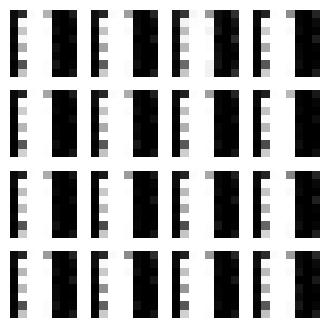

Epoch 11, Discriminator Loss: 1.1847, Generator Loss: 0.6203
Epoch 12, Discriminator Loss: 1.0938, Generator Loss: 0.8489
Epoch 13, Discriminator Loss: 1.1765, Generator Loss: 0.8301
Epoch 14, Discriminator Loss: 1.0820, Generator Loss: 1.0444
Epoch 15, Discriminator Loss: 0.8994, Generator Loss: 1.3737
Epoch 16, Discriminator Loss: 0.7244, Generator Loss: 1.5666
Epoch 17, Discriminator Loss: 0.6005, Generator Loss: 1.6977
Epoch 18, Discriminator Loss: 0.8967, Generator Loss: 0.9843
Epoch 19, Discriminator Loss: 1.2619, Generator Loss: 0.8133
Epoch 20, Discriminator Loss: 1.0555, Generator Loss: 1.2577


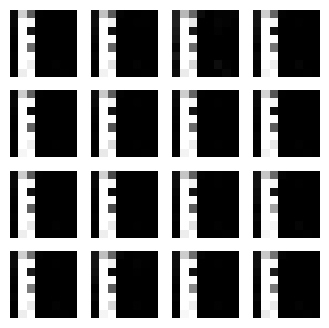

Epoch 21, Discriminator Loss: 1.6284, Generator Loss: 0.5582
Epoch 22, Discriminator Loss: 1.3963, Generator Loss: 0.6533
Epoch 23, Discriminator Loss: 0.9811, Generator Loss: 1.1605
Epoch 24, Discriminator Loss: 0.6397, Generator Loss: 1.6909
Epoch 25, Discriminator Loss: 0.4597, Generator Loss: 1.9513
Epoch 26, Discriminator Loss: 0.3319, Generator Loss: 2.2559
Epoch 27, Discriminator Loss: 0.2444, Generator Loss: 2.5787
Epoch 28, Discriminator Loss: 0.1866, Generator Loss: 2.9069
Epoch 29, Discriminator Loss: 0.1483, Generator Loss: 3.1598
Epoch 30, Discriminator Loss: 0.1129, Generator Loss: 3.3501


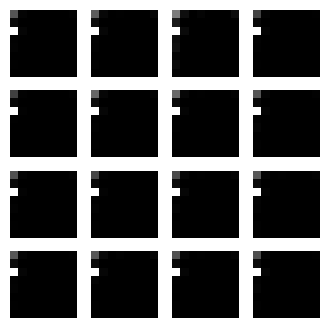

Epoch 31, Discriminator Loss: 0.0950, Generator Loss: 3.5501
Epoch 32, Discriminator Loss: 0.0796, Generator Loss: 3.7278
Epoch 33, Discriminator Loss: 0.0694, Generator Loss: 3.9122
Epoch 34, Discriminator Loss: 0.0559, Generator Loss: 4.0995
Epoch 35, Discriminator Loss: 0.0517, Generator Loss: 4.1837
Epoch 36, Discriminator Loss: 0.0473, Generator Loss: 4.3166
Epoch 37, Discriminator Loss: 0.0379, Generator Loss: 4.4441
Epoch 38, Discriminator Loss: 0.0361, Generator Loss: 4.5942
Epoch 39, Discriminator Loss: 0.0306, Generator Loss: 4.7067
Epoch 40, Discriminator Loss: 0.0275, Generator Loss: 4.8309


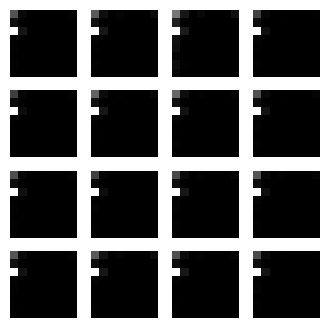

Epoch 41, Discriminator Loss: 0.0252, Generator Loss: 4.9052
Epoch 42, Discriminator Loss: 0.0222, Generator Loss: 5.0784
Epoch 43, Discriminator Loss: 0.0221, Generator Loss: 5.1384
Epoch 44, Discriminator Loss: 0.0195, Generator Loss: 5.2069
Epoch 45, Discriminator Loss: 0.0187, Generator Loss: 5.2943
Epoch 46, Discriminator Loss: 0.0193, Generator Loss: 5.1730
Epoch 47, Discriminator Loss: 0.0496, Generator Loss: 3.7677
Epoch 48, Discriminator Loss: 0.0681, Generator Loss: 3.3080
Epoch 49, Discriminator Loss: 0.1641, Generator Loss: 2.3767
Epoch 50, Discriminator Loss: 0.5567, Generator Loss: 1.7429


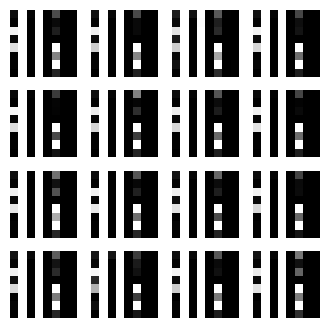

In [10]:
EPOCHS = 50
BATCH_SIZE = 128
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    current_batch_size = tf.shape(images)[0]
    noise = tf.random.normal([current_batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return disc_loss, gen_loss

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()

dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(len(images)).batch(BATCH_SIZE)

for epoch in range(EPOCHS):
    disc_losses = []
    gen_losses = []
    for image_batch in dataset:
        disc_loss, gen_loss = train_step(image_batch)
        disc_losses.append(disc_loss.numpy())
        gen_losses.append(gen_loss.numpy())

    print(f'Epoch {epoch + 1}, Discriminator Loss: {np.mean(disc_losses):.4f}, Generator Loss: {np.mean(gen_losses):.4f}')

    if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
        generate_and_save_images(generator, epoch + 1, seed)

In [11]:
test_noise = tf.random.normal([BATCH_SIZE, noise_dim])
generated_images = generator(test_noise, training=False)

real_labels = tf.ones((BATCH_SIZE, 1))
fake_labels = tf.zeros((BATCH_SIZE, 1))

real_predictions = discriminator(images[:BATCH_SIZE], training=False)
fake_predictions = discriminator(generated_images, training=False)

real_accuracy = tf.reduce_mean(tf.cast(tf.greater_equal(real_predictions, 0.5), tf.float32)).numpy()
fake_accuracy = tf.reduce_mean(tf.cast(tf.less(fake_predictions, 0.5), tf.float32)).numpy()

print(f'\nFinal Discriminator Accuracy on Real Images: {real_accuracy:.4f}')
print(f'Final Discriminator Accuracy on Fake Images: {fake_accuracy:.4f}')
print(f'Average Discriminator Accuracy: {(real_accuracy + fake_accuracy) / 2:.4f}')


Final Discriminator Accuracy on Real Images: 0.9531
Final Discriminator Accuracy on Fake Images: 1.0000
Average Discriminator Accuracy: 0.9766
